<a href="https://colab.research.google.com/github/henriquetamaki-max/Trilha_analise_dados/blob/main/Desafio_extra2_Henrique_Tamaki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importação e compreensão dos dados:
○ Carregamento do dataset em ambiente de análise (ex.: Google Colab);
○ Exploração inicial da estrutura dos dados.

In [40]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import pandas as pd
import numpy as np



In [11]:
# List files in the dataset to find the correct filename
dataset_path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
print("Files in dataset:", os.listdir(dataset_path))

# Load the correct file
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
file_path = csv_files[0]
print("Using file:", file_path)

# Load the latest version (with encoding fix for latin-1 files)
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "vivek468/superstore-dataset-final",
    file_path,
    pandas_kwargs={"encoding": "latin-1"},
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Files in dataset: ['Sample - Superstore.csv']
Using file: Sample - Superstore.csv


/tmp/ipykernel_20112/4179529717.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
First 5 records:    Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ... 

In [9]:
# Salvar uma cópia do DataFrame na pasta raiz do projeto (/content/)
output_path = "/content/Local_Superstore.csv"
df.to_csv(output_path, index=False, encoding="utf-8")
print(f"Arquivo salvo em: {output_path}")

Arquivo salvo em: /content/Local_Superstore.csv


Avaliação dos dados

In [12]:
# 1. Dimensões do dataset (linhas x colunas)
print("Dimensões do dataset:")
print(f"  Linhas: {df.shape[0]}")
print(f"  Colunas: {df.shape[1]}")

Dimensões do dataset:
  Linhas: 9994
  Colunas: 21


In [30]:
# 2. Colunas e tipos de dados
print("Colunas e tipos de dados:")
print(df.dtypes)

Colunas e tipos de dados:
row_id                        int64
order_id                     object
order_date           datetime64[ns]
ship_date            datetime64[ns]
ship_mode                    object
customer_id                  object
customer_name                object
segment                      object
country                      object
city                         object
state                        object
postal_code                   int64
region                       object
product_id                   object
category                     object
sub_category                 object
product_name                 object
sales                       float64
quantity                      int64
discount                    float64
profit                      float64
dias_para_entrega             int64
dtype: object


In [14]:
# 3. Informações gerais do dataset (tipos, memória, não-nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
# 4. Amostra dos primeiros 5 registros (head)
print("Primeiros 5 registros:")
df.head()

Primeiros 5 registros:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
# 5. Amostra dos últimos 5 registros (tail)
print("Últimos 5 registros:")
df.tail()

Últimos 5 registros:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [17]:
# 6. Top 20 registros
print("Top 20 registros:")
df.head(20)

Top 20 registros:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [18]:
# 7. Estatísticas descritivas das colunas numéricas
print("Estatísticas descritivas:")
df.describe()

Estatísticas descritivas:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [19]:
# 8. Verificar valores nulos por coluna
print("Valores nulos por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

Valores nulos por coluna:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total de valores nulos: 0


In [20]:
# 9. Valores únicos por coluna (cardinalidade)
print("Quantidade de valores únicos por coluna:")
print(df.nunique().sort_values())

Quantidade de valores únicos por coluna:
Country             1
Segment             3
Category            3
Ship Mode           4
Region              4
Discount           12
Quantity           14
Sub-Category       17
State              49
City              531
Postal Code       631
Customer Name     793
Customer ID       793
Order Date       1237
Ship Date        1334
Product Name     1850
Product ID       1862
Order ID         5009
Sales            5825
Profit           7287
Row ID           9994
dtype: int64


In [21]:
# 10. Top 20 produtos mais vendidos (por quantidade)
print("Top 20 produtos mais vendidos:")
df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(20)

Top 20 produtos mais vendidos:


,Quantity
Product Name,
Staples,215
Staple envelope,170
Easy-staple paper,150
Staples in misc. colors,86
KI Adjustable-Height Table,74
Storex Dura Pro Binders,71
Avery Non-Stick Binders,71
GBC Premium Transparent Covers with Diagonal Lined Pattern,67
"Situations Contoured Folding Chairs, 4/Set",64


In [22]:
# 11. Top 20 clientes por valor de vendas
print("Top 20 clientes por valor de vendas:")
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(20)

Top 20 clientes por valor de vendas:


,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


In [23]:
# 12. Distribuição por categoria e subcategoria
print("Contagem por Categoria:")
print(df["Category"].value_counts())
print("\nContagem por Sub-Categoria:")
print(df["Sub-Category"].value_counts())

Contagem por Categoria:
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Contagem por Sub-Categoria:
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


2. Tratamento e preparação dos dados:
○ Verifi cação e tratamento de valores nulos ou duplicados;
○ Conversão de tipos de dados (datas e valores numéricos);
○ Organização e padronização das colunas;
○ Identifi cação e tratamento de possíveis outliers.

In [24]:
# ─── 2.1 Verificação e tratamento de valores nulos e duplicados ───────────────

# --- Valores nulos ---
print("=" * 55)
print("VALORES NULOS POR COLUNA")
print("=" * 55)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado.")
print(f"Total de valores nulos: {nulos.sum()}")

# --- Linhas duplicadas ---
print("\n" + "=" * 55)
print("LINHAS DUPLICADAS")
print("=" * 55)
duplicadas = df.duplicated().sum()
print(f"Total de linhas duplicadas: {duplicadas}")

if duplicadas > 0:
    print("Removendo duplicatas...")
    df = df.drop_duplicates()
    print(f"Linhas após remoção: {df.shape[0]}")
else:
    print("Nenhuma duplicata encontrada. Dataset íntegro.")

VALORES NULOS POR COLUNA
Nenhum valor nulo encontrado.
Total de valores nulos: 0

LINHAS DUPLICADAS
Total de linhas duplicadas: 0
Nenhuma duplicata encontrada. Dataset íntegro.


In [26]:
# ─── 2.2 Conversão de tipos de dados (datas e valores numéricos) ──────────────

print("Tipos de dados ANTES da conversão:")
print(df[["Order Date", "Ship Date", "Sales", "Quantity", "Discount", "Profit"]].dtypes)

# Converter colunas de data de string para datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=False)
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=False)

# Garantir que colunas numéricas estão com o tipo correto
df["Sales"]    = pd.to_numeric(df["Sales"],    errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").astype("int64")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
df["Profit"]   = pd.to_numeric(df["Profit"],   errors="coerce")

print("\nTipos de dados APÓS a conversão:")
print(df[["Order Date", "Ship Date", "Sales", "Quantity", "Discount", "Profit"]].dtypes)

# Criar coluna auxiliar: dias para entrega
df["Dias para Entrega"] = (df["Ship Date"] - df["Order Date"]).dt.days
print(f"\nColuna 'Dias para Entrega' criada.")
print(f"Média de dias para entrega: {df['Dias para Entrega'].mean():.1f} dias")
print(f"Máximo: {df['Dias para Entrega'].max()} dias | Mínimo: {df['Dias para Entrega'].min()} dias")

Tipos de dados ANTES da conversão:
Order Date     object
Ship Date      object
Sales         float64
Quantity        int64
Discount      float64
Profit        float64
dtype: object

Tipos de dados APÓS a conversão:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
Sales                float64
Quantity               int64
Discount             float64
Profit               float64
dtype: object

Coluna 'Dias para Entrega' criada.
Média de dias para entrega: 4.0 dias
Máximo: 7 dias | Mínimo: 0 dias


In [27]:
# ─── 2.3 Organização e padronização das colunas ──────────────────────────────

print("Colunas ANTES da padronização:")
print(df.columns.tolist())

# Renomear colunas: substituir espaços por underscore e converter para snake_case
df.columns = (
    df.columns
    .str.strip()                     # remove espaços no início/fim
    .str.lower()                     # tudo minúsculo
    .str.replace(" ", "_", regex=False)   # espaços → underscore
    .str.replace("-", "_", regex=False)   # hífens → underscore
)

print("\nColunas APÓS a padronização:")
print(df.columns.tolist())

# Padronizar campos de texto: strip de espaços extras
str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].str.strip()

print(f"\nPadronização de espaços aplicada em {len(str_cols)} colunas de texto.")
print("\nAmostra do DataFrame com colunas padronizadas:")
df.head(3)

Colunas ANTES da padronização:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Dias para Entrega']

Colunas APÓS a padronização:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'dias_para_entrega']

Padronização de espaços aplicada em 13 colunas de texto.

Amostra do DataFrame com colunas padronizadas:


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,dias_para_entrega
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,4


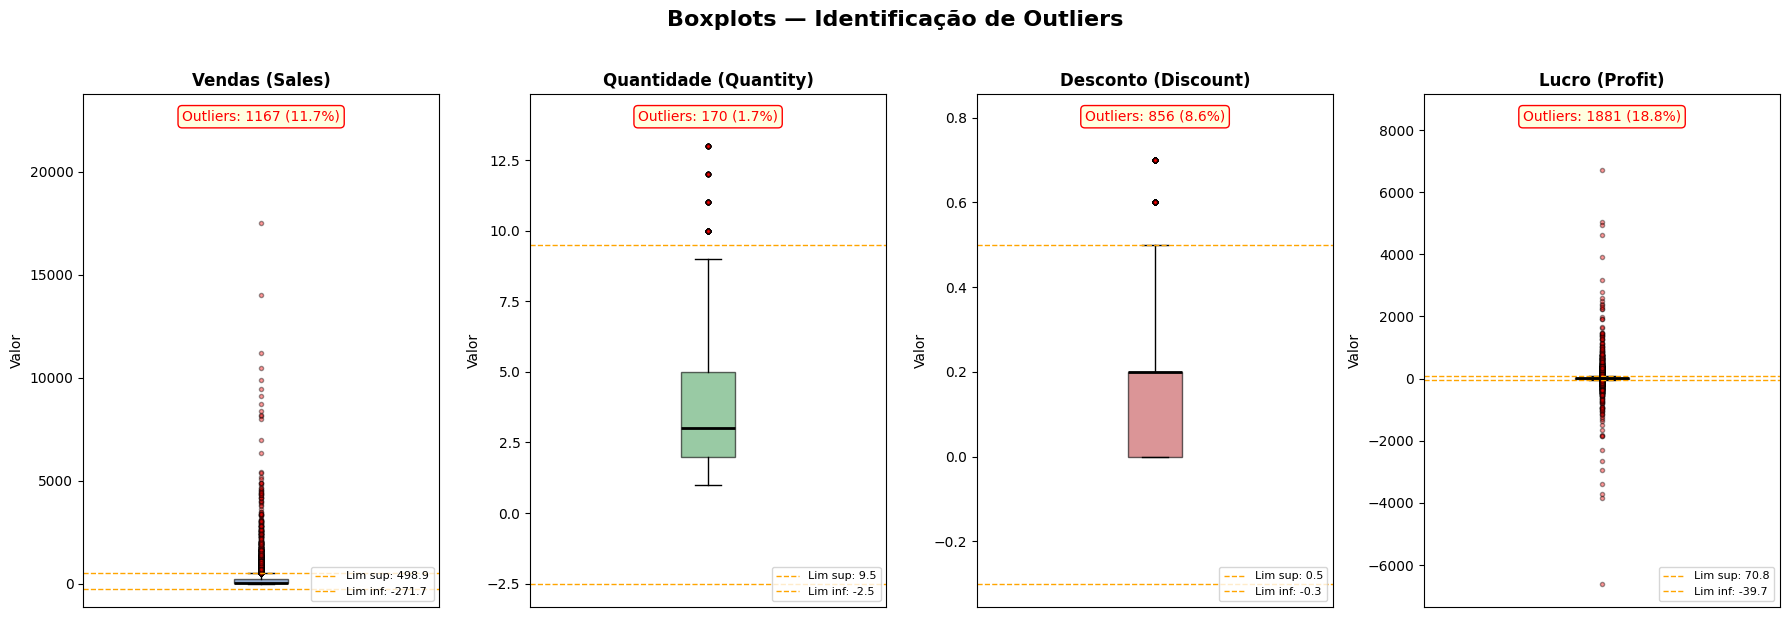

Gráfico salvo em /content/boxplots_outliers.png


In [31]:
# ─── Gráfico 1: Boxplots — Visualizando outliers por variável numérica ────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

num_cols = ["sales", "quantity", "discount", "profit"]
labels   = ["Vendas (Sales)", "Quantidade (Quantity)", "Desconto (Discount)", "Lucro (Profit)"]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("Boxplots — Identificação de Outliers", fontsize=16, fontweight="bold", y=1.02)

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, col, label, color in zip(axes, num_cols, labels, colors):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    # Separar outliers dos dados normais
    outliers = df[col][(df[col] < lim_inf) | (df[col] > lim_sup)]
    normais  = df[col][(df[col] >= lim_inf) & (df[col] <= lim_sup)]

    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="red",
                               markersize=3, alpha=0.4, linestyle="none"))
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel("Valor")
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    # Anotação com contagem de outliers
    n_out = len(outliers)
    pct   = n_out / len(df[col]) * 100
    ax.text(0.5, 0.97, f"Outliers: {n_out} ({pct:.1f}%)",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=10, color="red",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="red"))

    # Linhas de limite IQR
    ax.axhline(lim_sup, color="orange", linestyle="--", linewidth=1, label=f"Lim sup: {lim_sup:.1f}")
    ax.axhline(lim_inf, color="orange", linestyle="--", linewidth=1, label=f"Lim inf: {lim_inf:.1f}")
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("/content/boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em /content/boxplots_outliers.png")

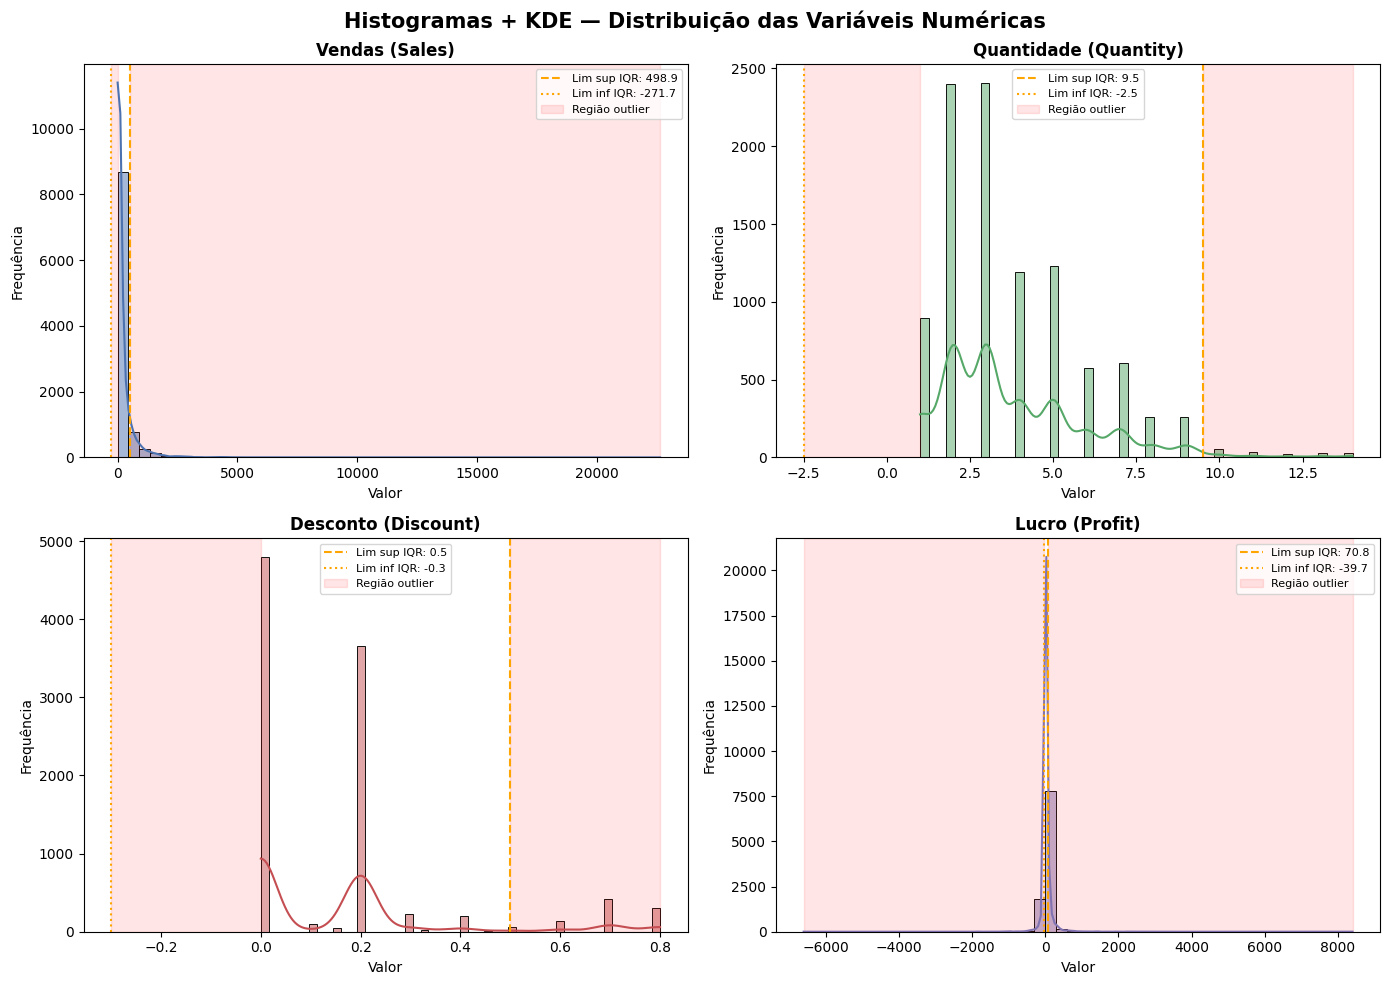

Gráfico salvo em /content/histogramas_outliers.png


In [32]:
# ─── Gráfico 2: Histogramas + KDE — Distribuição e caudas longas ──────────────

num_cols = ["sales", "quantity", "discount", "profit"]
labels   = ["Vendas (Sales)", "Quantidade (Quantity)", "Desconto (Discount)", "Lucro (Profit)"]
colors   = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Histogramas + KDE — Distribuição das Variáveis Numéricas", fontsize=15, fontweight="bold")
axes = axes.flatten()

for ax, col, label, color in zip(axes, num_cols, labels, colors):
    Q1      = df[col].quantile(0.25)
    Q3      = df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    # Histograma + KDE
    sns.histplot(df[col], kde=True, ax=ax, color=color, alpha=0.5, bins=50)

    # Marcar limites IQR
    ax.axvline(lim_sup, color="orange", linestyle="--", linewidth=1.5, label=f"Lim sup IQR: {lim_sup:.1f}")
    ax.axvline(lim_inf, color="orange", linestyle=":",  linewidth=1.5, label=f"Lim inf IQR: {lim_inf:.1f}")

    # Sombrear região de outliers
    ymax = ax.get_ylim()[1]
    ax.axvspan(df[col].min(), lim_inf, alpha=0.1, color="red", label="Região outlier")
    ax.axvspan(lim_sup, df[col].max(), alpha=0.1, color="red")

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/histogramas_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em /content/histogramas_outliers.png")

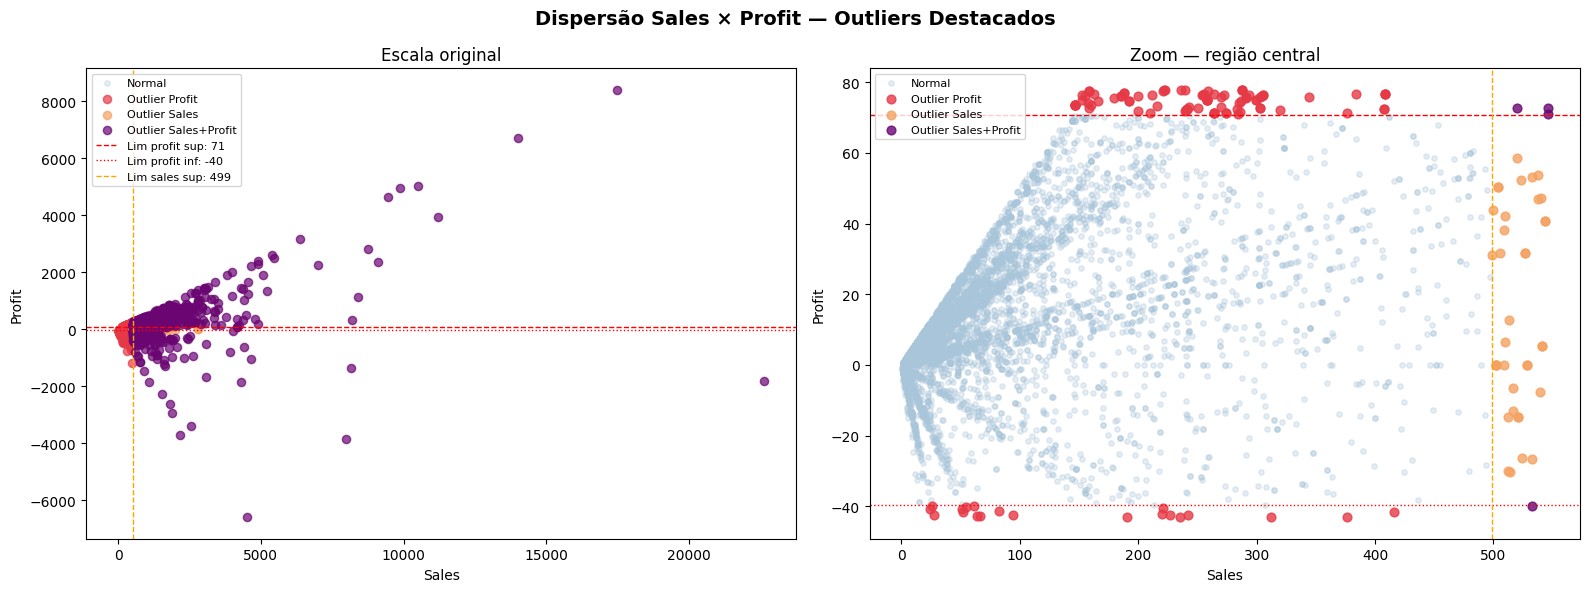

Contagem por tipo:
tipo
Normal                  7874
Outlier Profit           953
Outlier Sales+Profit     928
Outlier Sales            239


In [33]:
# ─── Gráfico 3: Scatter Sales vs Profit — Outliers em destaque ───────────────

# Calcular limites IQR para sales e profit
def iqr_limits(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

s_inf, s_sup = iqr_limits(df["sales"])
p_inf, p_sup = iqr_limits(df["profit"])

# Classificar cada ponto
def classifica(row):
    is_s_out = row["sales"]  < s_inf or row["sales"]  > s_sup
    is_p_out = row["profit"] < p_inf or row["profit"] > p_sup
    if is_s_out and is_p_out: return "Outlier Sales+Profit"
    if is_s_out:               return "Outlier Sales"
    if is_p_out:               return "Outlier Profit"
    return "Normal"

df["tipo"] = df.apply(classifica, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Dispersão Sales × Profit — Outliers Destacados", fontsize=14, fontweight="bold")

palette = {"Normal": "#A8C5DA", "Outlier Sales": "#F4A261",
           "Outlier Profit": "#E63946", "Outlier Sales+Profit": "#6A0572"}

# Gráfico 1: escala original
for tipo, grupo in df.groupby("tipo"):
    size  = 15 if tipo == "Normal" else 35
    alpha = 0.3 if tipo == "Normal" else 0.7
    axes[0].scatter(grupo["sales"], grupo["profit"],
                    c=palette[tipo], label=tipo, s=size, alpha=alpha)
axes[0].axhline(p_sup, color="red",    linestyle="--", linewidth=1, label=f"Lim profit sup: {p_sup:.0f}")
axes[0].axhline(p_inf, color="red",    linestyle=":",  linewidth=1, label=f"Lim profit inf: {p_inf:.0f}")
axes[0].axvline(s_sup, color="orange", linestyle="--", linewidth=1, label=f"Lim sales sup: {s_sup:.0f}")
axes[0].set_title("Escala original", fontsize=12)
axes[0].set_xlabel("Sales"); axes[0].set_ylabel("Profit")
axes[0].legend(fontsize=8, loc="upper left")

# Gráfico 2: zoom na região normal (sem extremos)
df_zoom = df[(df["sales"] <= s_sup*1.1) & (df["profit"].between(p_inf*1.1, p_sup*1.1))]
for tipo, grupo in df_zoom.groupby("tipo"):
    size  = 15 if tipo == "Normal" else 40
    alpha = 0.3 if tipo == "Normal" else 0.8
    axes[1].scatter(grupo["sales"], grupo["profit"],
                    c=palette[tipo], label=tipo, s=size, alpha=alpha)
axes[1].axhline(p_sup, color="red",    linestyle="--", linewidth=1)
axes[1].axhline(p_inf, color="red",    linestyle=":",  linewidth=1)
axes[1].axvline(s_sup, color="orange", linestyle="--", linewidth=1)
axes[1].set_title("Zoom — região central", fontsize=12)
axes[1].set_xlabel("Sales"); axes[1].set_ylabel("Profit")
axes[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("/content/scatter_sales_profit.png", dpi=150, bbox_inches="tight")
plt.show()

contagem = df["tipo"].value_counts()
print("Contagem por tipo:")
print(contagem.to_string())
# Limpar coluna auxiliar
df.drop(columns=["tipo"], inplace=True)

In [28]:
# ─── 2.4 Identificação e tratamento de outliers (método IQR) ─────────────────
import numpy as np

num_cols = ["sales", "quantity", "discount", "profit"]

print(f"{'Coluna':<12} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lim Inf':>12} {'Lim Sup':>12} {'Outliers':>10}")
print("-" * 76)

outlier_summary = {}
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out   = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    outlier_summary[col] = {"lim_inf": lim_inf, "lim_sup": lim_sup, "n_outliers": n_out}
    print(f"{col:<12} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {lim_inf:>12.2f} {lim_sup:>12.2f} {n_out:>10}")

# Criar cópia do dataset sem outliers extremos (usando IQR em sales e profit)
df_clean = df.copy()
for col in ["sales", "profit"]:
    li = outlier_summary[col]["lim_inf"]
    ls = outlier_summary[col]["lim_sup"]
    df_clean = df_clean[(df_clean[col] >= li) & (df_clean[col] <= ls)]

print(f"\nLinhas originais : {len(df)}")
print(f"Linhas sem outliers extremos (sales/profit): {len(df_clean)}")
print(f"Outliers removidos: {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")
print("\nDataset limpo salvo em 'df_clean' para análises posteriores.")

Coluna               Q1         Q3        IQR      Lim Inf      Lim Sup   Outliers
----------------------------------------------------------------------------
sales             17.28     209.94     192.66      -271.71       498.93       1167
quantity           2.00       5.00       3.00        -2.50         9.50        170
discount           0.00       0.20       0.20        -0.30         0.50        856
profit             1.73      29.36      27.64       -39.72        70.82       1881

Linhas originais : 9994
Linhas sem outliers extremos (sales/profit): 7874
Outliers removidos: 2120 (21.2%)

Dataset limpo salvo em 'df_clean' para análises posteriores.


In [34]:
# ─── 2.5 Coluna %lucro: margem de lucro sobre as vendas ──────────────────────────
import numpy as np

# Calcula profit / sales, evitando divisão por zero (sales == 0 → NaN)
df_clean["pct_lucro"] = np.where(
    df_clean["sales"] != 0,
    df_clean["profit"] / df_clean["sales"],
    np.nan
)

print("Coluna 'pct_lucro' adicionada a df_clean.")
print(f"Total de linhas: {len(df_clean)}")
print(f"Valores nulos (sales=0): {df_clean['pct_lucro'].isna().sum()}")

print("\nEstatísticas da coluna pct_lucro:")
print(df_clean["pct_lucro"].describe().apply(lambda x: f"{x:.4f}"))

print("\nAmostra (primeiros 10 registros com as colunas principais):")
df_clean[["order_id", "product_name", "sales", "profit", "pct_lucro"]].head(10)

Coluna 'pct_lucro' adicionada a df_clean.
Total de linhas: 7874
Valores nulos (sales=0): 0

Estatísticas da coluna pct_lucro:
count    7874.0000
mean        0.1552
std         0.4280
min        -2.7500
25%         0.0875
50%         0.2875
75%         0.3750
max         0.5000
Name: pct_lucro, dtype: object

Amostra (primeiros 10 registros com as colunas principais):


,order_id,product_name,sales,profit,pct_lucro
0,CA-2016-152156,Bush Somerset Collection Bookcase,261.960,41.9136,0.1600
2,CA-2016-138688,Self-Adhesive Address Labels for Typewriters b...,14.620,6.8714,0.4700
4,US-2015-108966,Eldon Fold 'N Roll Cart System,22.368,2.5164,0.1125
5,CA-2014-115812,Eldon Expressions Wood and Plastic Desk Access...,48.860,14.1694,0.2900
6,CA-2014-115812,Newell 322,7.280,1.9656,0.2700
8,CA-2014-115812,DXL Angle-View Binders with Locking Rings by S...,18.504,5.7825,0.3125
9,CA-2014-115812,Belkin F5C206VTEL 6 Outlet Surge,114.900,34.4700,0.3000
12,CA-2017-114412,Xerox 1967,15.552,5.4432,0.3500
15,US-2015-118983,Storex DuraTech Recycled Plastic Frosted Binders,2.544,-3.8160,-1.5000
17,CA-2014-167164,Fellowes Super Stor/Drawer,55.500,9.9900,0.1800


3.Análise exploratória:
○ Aplicação de fi ltros, ordenações e agrupamentos (GroupBy);
○ Análise das variáveis relevantes do dataset;
○ Geração de visualizações gráfi cas para apoiar a interpretação dos dados;
○ Investigação de relações entre variáveis (ex.: desconto vs lucro).

In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. ANÁLISE EXPLORATÓRIA
# ═══════════════════════════════════════════════════════════════════════════════

# ─── 3.1 Filtros e Ordenações ─────────────────────────────────────────────────

print("=" * 60)
print("TOP 10 PRODUTOS — Maior Receita de Vendas")
print("=" * 60)
top_produtos_sales = (df_clean.groupby("product_name")["sales"]
                      .sum().sort_values(ascending=False).head(10))
print(top_produtos_sales.to_string())

print("\n" + "=" * 60)
print("TOP 10 PRODUTOS — Maior Lucro Total")
print("=" * 60)
top_produtos_profit = (df_clean.groupby("product_name")["profit"]
                       .sum().sort_values(ascending=False).head(10))
print(top_produtos_profit.to_string())

print("\n" + "=" * 60)
print("TOP 10 PRODUTOS — Maior Margem de Lucro (mín 10 vendas)")
print("=" * 60)
margem_produto = (df_clean.groupby("product_name")
                  .agg(total_sales=("sales","sum"),
                       total_profit=("profit","sum"),
                       qtd=("sales","count"))
                  .query("qtd >= 10"))
margem_produto["margem"] = margem_produto["total_profit"] / margem_produto["total_sales"]
print(margem_produto.sort_values("margem", ascending=False).head(10)[["total_sales","total_profit","margem"]].to_string())

print("\n" + "=" * 60)
print("TOP 10 CLIENTES — Maior Receita")
print("=" * 60)
top_clientes = (df_clean.groupby("customer_name")
                .agg(total_sales=("sales","sum"),
                     total_profit=("profit","sum"),
                     pedidos=("order_id","nunique"))
                .sort_values("total_sales", ascending=False).head(10))
print(top_clientes.to_string())

TOP 10 PRODUTOS — Maior Receita de Vendas
product_name
Situations Contoured Folding Chairs, 4/Set                                         2321.046
Fellowes Officeware Wire Shelving                                                  2299.648
Lesro Sheffield Collection Coffee Table, End Table, Center Table, Corner Table     2298.114
DMI Arturo Collection Mission-style Design Wood Chair                              2204.308
Easy-staple paper                                                                  2159.052
Space Solutions HD Industrial Steel Shelving.                                      2069.460
Carina Double Wide Media Storage Towers in Natural & Black                         2040.696
Global Leather Highback Executive Chair with Pneumatic Height Adjustment, Black    1989.702
Global Wood Trimmed Manager's Task Chair, Khaki                                    1965.168
AT&T 1080 Corded phone                                                             1945.258

TOP 10 PRODUTOS — Maior 

In [36]:
# ─── 3.2 GroupBy — Vendas, Lucro e Margem por dimensões-chave ────────────────

dims = {
    "Categoria":      "category",
    "Sub-Categoria":  "sub_category",
    "Segmento":       "segment",
    "Região":         "region",
    "Modo de Envio":  "ship_mode",
}

for titulo, col in dims.items():
    grp = (df_clean.groupby(col)
           .agg(total_vendas  =("sales",  "sum"),
                total_lucro   =("profit", "sum"),
                qtd_pedidos   =("order_id","count"),
                margem_media  =("pct_lucro","mean"))
           .sort_values("total_vendas", ascending=False))
    grp["margem_media"] = grp["margem_media"].map(lambda x: f"{x*100:.1f}%")
    grp["total_vendas"] = grp["total_vendas"].map(lambda x: f"$ {x:,.0f}")
    grp["total_lucro"]  = grp["total_lucro"].map(lambda x: f"$ {x:,.0f}")
    print("\n" + "=" * 65)
    print(f"  POR {titulo.upper()}")
    print("=" * 65)
    print(grp.to_string())


  POR CATEGORIA
                total_vendas total_lucro  qtd_pedidos margem_media
category                                                          
Office Supplies    $ 237,898    $ 53,302         5281        16.7%
Furniture          $ 169,867    $ 13,444         1380        11.4%
Technology         $ 149,139    $ 21,207         1213        15.0%

  POR SUB-CATEGORIA
             total_vendas total_lucro  qtd_pedidos margem_media
sub_category                                                   
Phones           $ 82,761     $ 9,308          578        10.8%
Storage          $ 73,327     $ 5,523          639         9.4%
Chairs           $ 69,799     $ 2,383          324         2.8%
Accessories      $ 61,527    $ 11,300          610        19.4%
Furnishings      $ 52,839     $ 9,828          851        17.1%
Paper            $ 46,935    $ 19,841         1248        42.3%
Binders          $ 36,735     $ 7,183         1314       -18.5%
Appliances       $ 28,323     $ 5,800          324 

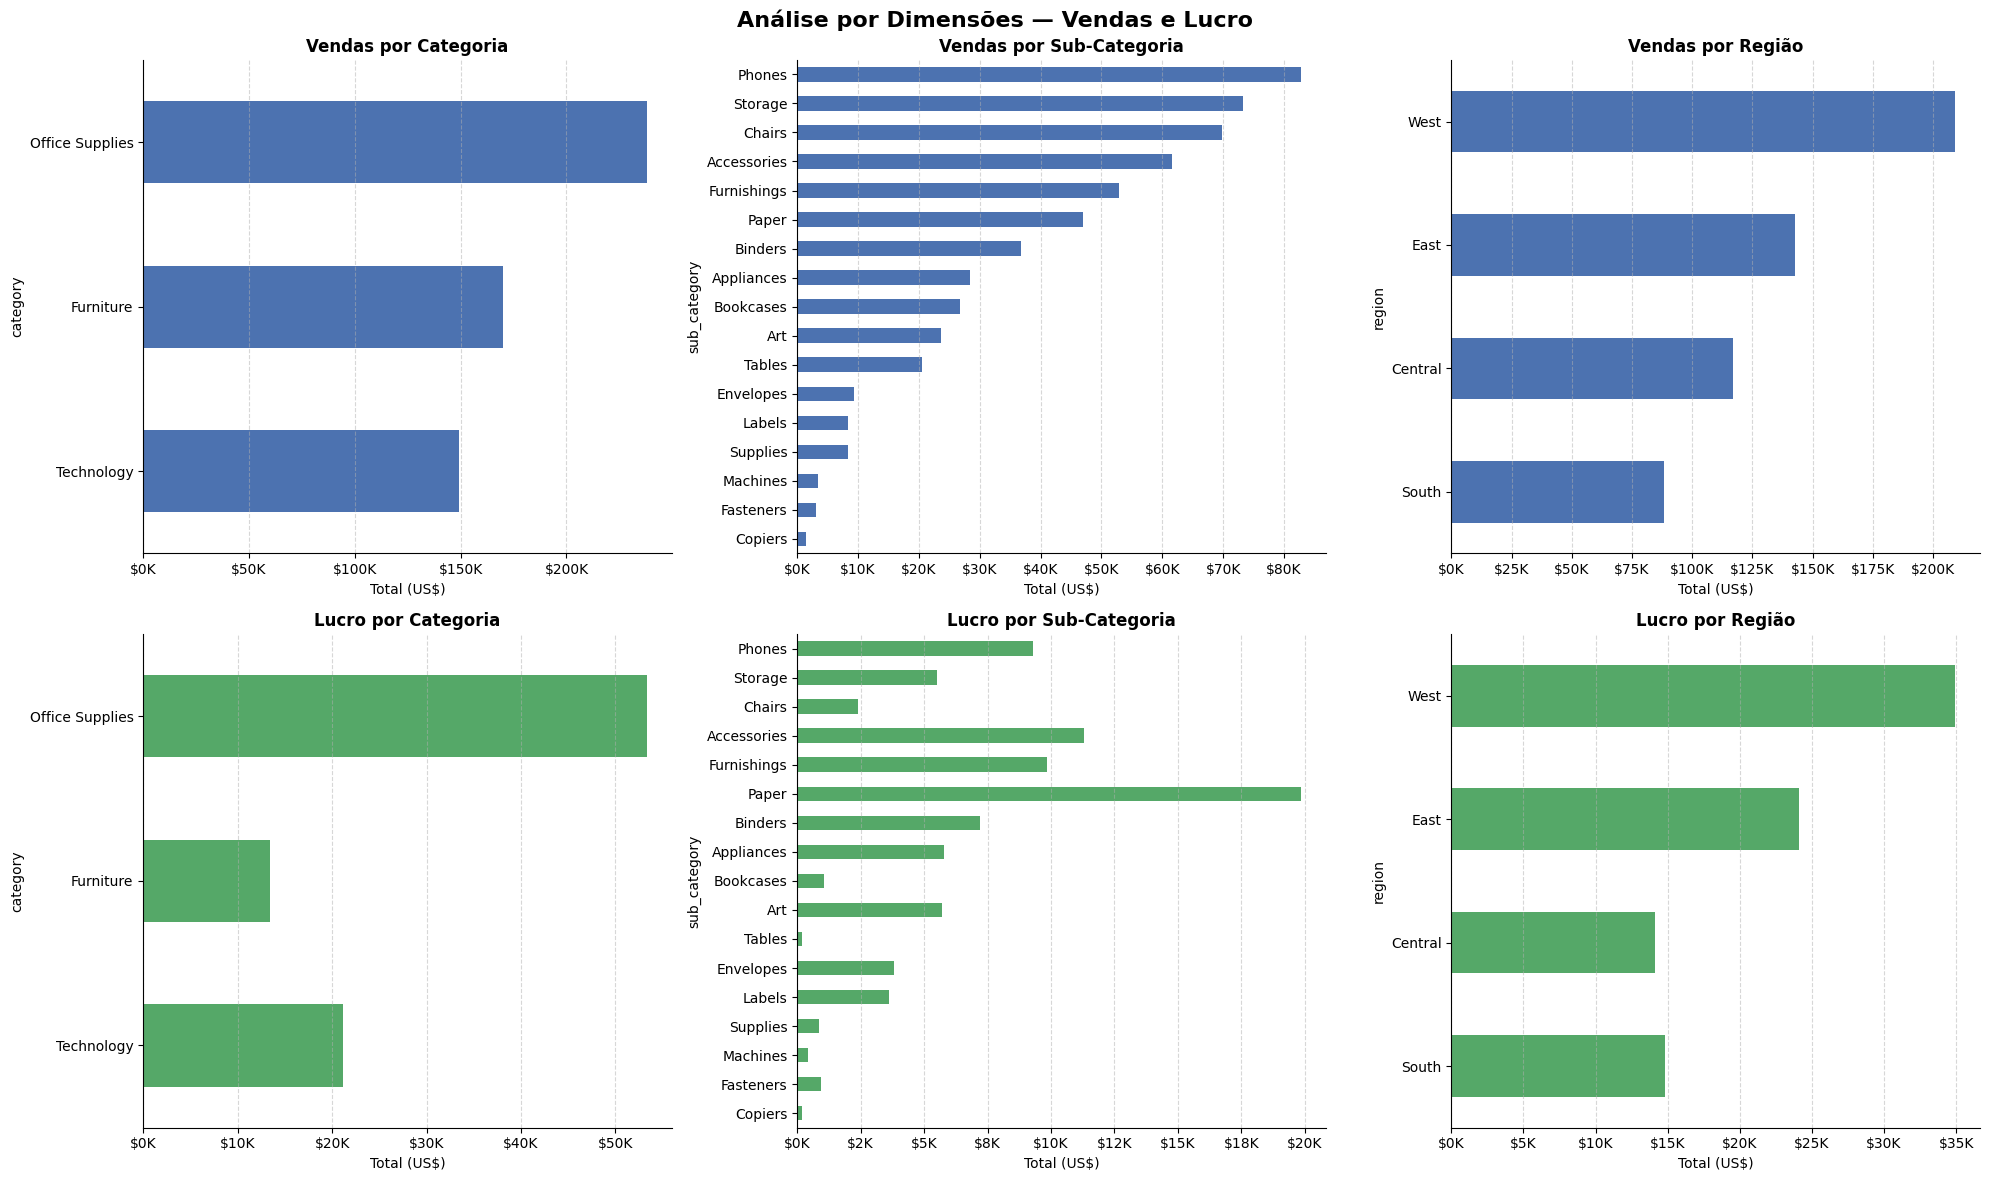

Gráfico salvo em /content/barras_dimensoes.png


In [37]:
# ─── 3.3 Gráficos de barras — Ranking por Categoria, Sub-Categoria e Região ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Análise por Dimensões — Vendas e Lucro', fontsize=16, fontweight='bold')

palette_sales  = '#4C72B0'
palette_profit = '#55A868'

# --- Categoria ---
cat = (df_clean.groupby('category')
       .agg(sales=('sales','sum'), profit=('profit','sum'))
       .sort_values('sales', ascending=True))
cat['sales'].plot(kind='barh', ax=axes[0,0], color=palette_sales)
axes[0,0].set_title('Vendas por Categoria', fontweight='bold')
axes[0,0].set_xlabel('Total (US$)')
cat['profit'].plot(kind='barh', ax=axes[1,0], color=palette_profit)
axes[1,0].set_title('Lucro por Categoria', fontweight='bold')
axes[1,0].set_xlabel('Total (US$)')

# --- Sub-Categoria ---
sub = (df_clean.groupby('sub_category')
       .agg(sales=('sales','sum'), profit=('profit','sum'))
       .sort_values('sales', ascending=True))
sub['sales'].plot(kind='barh', ax=axes[0,1], color=palette_sales)
axes[0,1].set_title('Vendas por Sub-Categoria', fontweight='bold')
axes[0,1].set_xlabel('Total (US$)')
sub['profit'].plot(kind='barh', ax=axes[1,1], color=palette_profit)
axes[1,1].set_title('Lucro por Sub-Categoria', fontweight='bold')
axes[1,1].set_xlabel('Total (US$)')
for bar, val in zip(axes[1,1].patches, sub['profit']):
    if val < 0: bar.set_color('#E63946')

# --- Região ---
reg = (df_clean.groupby('region')
       .agg(sales=('sales','sum'), profit=('profit','sum'))
       .sort_values('sales', ascending=True))
reg['sales'].plot(kind='barh', ax=axes[0,2], color=palette_sales)
axes[0,2].set_title('Vendas por Região', fontweight='bold')
axes[0,2].set_xlabel('Total (US$)')
reg['profit'].plot(kind='barh', ax=axes[1,2], color=palette_profit)
axes[1,2].set_title('Lucro por Região', fontweight='bold')
axes[1,2].set_xlabel('Total (US$)')

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/barras_dimensoes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em /content/barras_dimensoes.png')

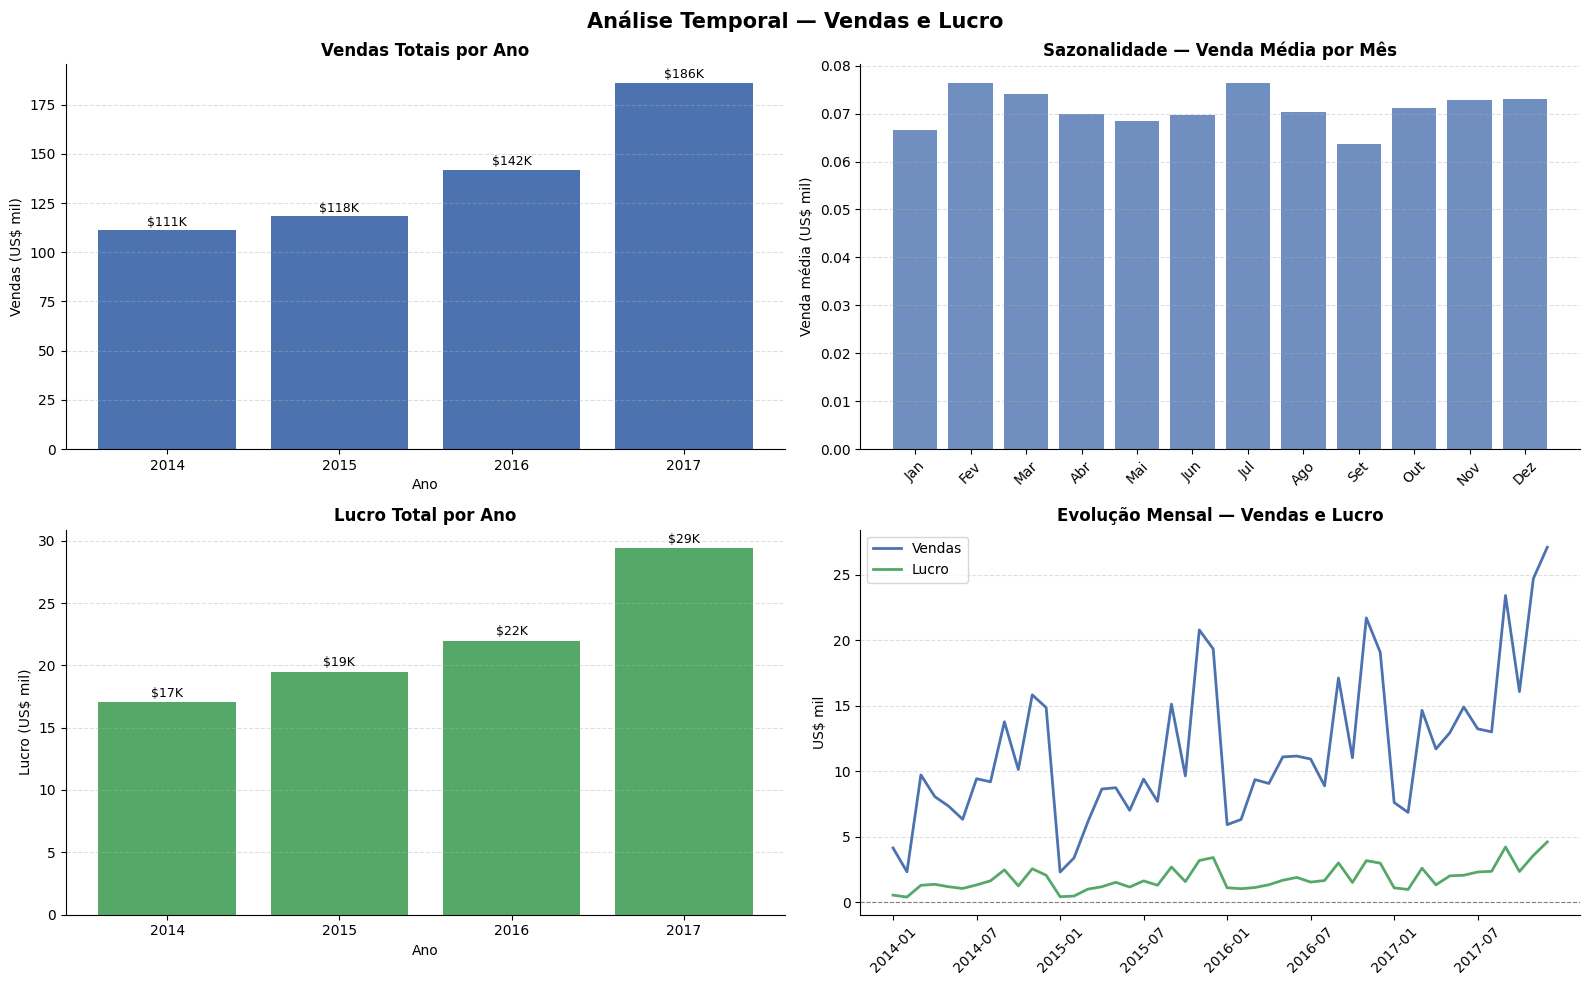

Gráfico salvo em /content/temporal.png


In [38]:
# ─── 3.4 Análise Temporal — Vendas e Lucro por Ano e Mês ─────────────────

# Extrair ano e mês
df_clean['ano']  = df_clean['order_date'].dt.year
df_clean['mes']  = df_clean['order_date'].dt.month
df_clean['ano_mes'] = df_clean['order_date'].dt.to_period('M')

# Agrupamento por ano
by_year = (df_clean.groupby('ano')
           .agg(vendas=('sales','sum'), lucro=('profit','sum'))
           .reset_index())

# Agrupamento por mes (media de todos os anos)
by_month = (df_clean.groupby('mes')
            .agg(vendas=('sales','mean'), lucro=('profit','mean'))
            .reset_index())

# Agrupamento por ano+mes
by_anomes = (df_clean.groupby('ano_mes')
             .agg(vendas=('sales','sum'), lucro=('profit','sum'))
             .reset_index())
by_anomes['ano_mes_str'] = by_anomes['ano_mes'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análise Temporal — Vendas e Lucro', fontsize=15, fontweight='bold')

meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# Vendas por ano
axes[0,0].bar(by_year['ano'].astype(str), by_year['vendas']/1e3, color='#4C72B0')
axes[0,0].set_title('Vendas Totais por Ano', fontweight='bold')
axes[0,0].set_ylabel('Vendas (US$ mil)')
axes[0,0].set_xlabel('Ano')
for bar, val in zip(axes[0,0].patches, by_year['vendas']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=9)

# Lucro por ano
axes[1,0].bar(by_year['ano'].astype(str), by_year['lucro']/1e3, color='#55A868')
axes[1,0].set_title('Lucro Total por Ano', fontweight='bold')
axes[1,0].set_ylabel('Lucro (US$ mil)')
axes[1,0].set_xlabel('Ano')
for bar, val in zip(axes[1,0].patches, by_year['lucro']):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=9)

# Vendas médias por mês
axes[0,1].bar(range(1,13), by_month['vendas']/1e3, color='#4C72B0', alpha=0.8)
axes[0,1].set_title('Sazonalidade — Venda Média por Mês', fontweight='bold')
axes[0,1].set_ylabel('Venda média (US$ mil)')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(meses, rotation=45)

# Evolução mensal
x_ticks = range(0, len(by_anomes), 6)
axes[1,1].plot(range(len(by_anomes)), by_anomes['vendas']/1e3,
               color='#4C72B0', linewidth=2, label='Vendas')
axes[1,1].plot(range(len(by_anomes)), by_anomes['lucro']/1e3,
               color='#55A868', linewidth=2, label='Lucro')
axes[1,1].set_title('Evolução Mensal — Vendas e Lucro', fontweight='bold')
axes[1,1].set_ylabel('US$ mil')
axes[1,1].set_xticks(list(x_ticks))
axes[1,1].set_xticklabels([by_anomes['ano_mes_str'].iloc[i] for i in x_ticks], rotation=45)
axes[1,1].legend()
axes[1,1].axhline(0, color='gray', linewidth=0.8, linestyle='--')

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em /content/temporal.png')

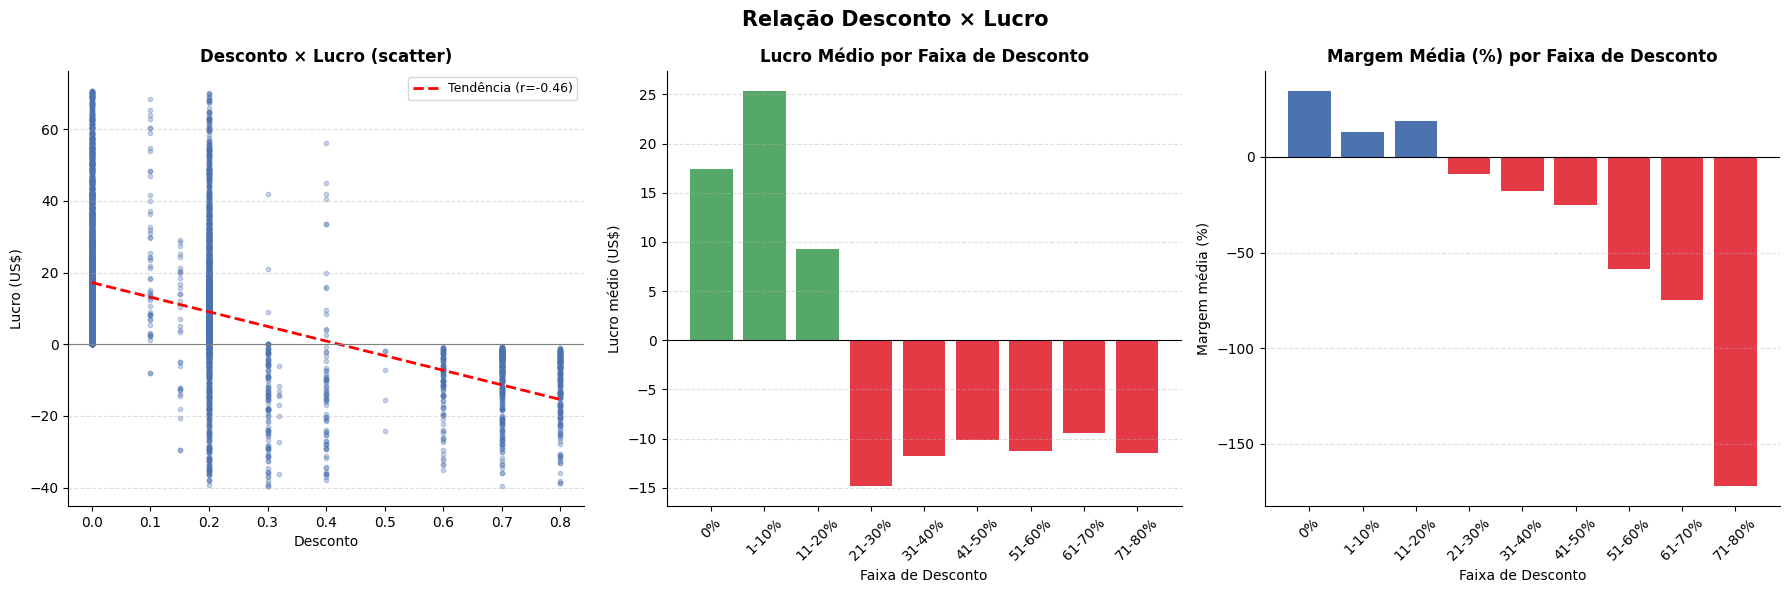

Correlação de Pearson (Desconto x Lucro): r = -0.4550  (p-value = 0.00e+00)

Média de lucro e margem por faixa de desconto:
faixa_desc  lucro_medio  margem_media  contagem
        0%    17.447278      0.346930      3834
     1-10%    25.385143      0.131237        53
    11-20%     9.291407      0.188702      3137
    21-30%   -14.856620     -0.091582       112
    31-40%   -11.737388     -0.175677        84
    41-50%   -10.145360     -0.252000         5
    51-60%   -11.251002     -0.587260       104
    61-70%    -9.396476     -0.746279       327
    71-80%   -11.417314     -1.723165       218


In [39]:
# ─── 3.5 Relação Desconto × Lucro — Investigação e Correlação ────────────
import seaborn as sns
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Relação Desconto × Lucro', fontsize=15, fontweight='bold')

# --- Scatter desconto x lucro com linha de tendência ---
ax = axes[0]
ax.scatter(df_clean['discount'], df_clean['profit'],
           alpha=0.3, s=10, color='#4C72B0')
m, b, r, p, _ = stats.linregress(df_clean['discount'], df_clean['profit'])
x_line = np.linspace(df_clean['discount'].min(), df_clean['discount'].max(), 100)
ax.plot(x_line, m*x_line+b, 'r--', linewidth=2, label=f'Tendência (r={r:.2f})')
ax.axhline(0, color='gray', linestyle='-', linewidth=0.8)
ax.set_title('Desconto × Lucro (scatter)', fontweight='bold')
ax.set_xlabel('Desconto'); ax.set_ylabel('Lucro (US$)')
ax.legend(fontsize=9)

# --- Média de lucro e margem por faixa de desconto ---
df_clean['faixa_desc'] = pd.cut(df_clean['discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0],
    labels=['0%','1-10%','11-20%','21-30%','31-40%','41-50%','51-60%','61-70%','71-80%','81-100%'])

faixa_grp = (df_clean.groupby('faixa_desc', observed=True)
             .agg(lucro_medio=('profit','mean'),
                  margem_media=('pct_lucro','mean'),
                  contagem=('profit','count'))
             .reset_index())

# Barras de lucro médio por faixa
cores = ['#55A868' if v >= 0 else '#E63946' for v in faixa_grp['lucro_medio']]
axes[1].bar(faixa_grp['faixa_desc'].astype(str), faixa_grp['lucro_medio'], color=cores)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Lucro Médio por Faixa de Desconto', fontweight='bold')
axes[1].set_xlabel('Faixa de Desconto'); axes[1].set_ylabel('Lucro médio (US$)')
axes[1].tick_params(axis='x', rotation=45)

# Margem média por faixa
cores2 = ['#4C72B0' if v >= 0 else '#E63946' for v in faixa_grp['margem_media']]
axes[2].bar(faixa_grp['faixa_desc'].astype(str), faixa_grp['margem_media']*100, color=cores2)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Margem Média (%) por Faixa de Desconto', fontweight='bold')
axes[2].set_xlabel('Faixa de Desconto'); axes[2].set_ylabel('Margem média (%)')
axes[2].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/desconto_vs_lucro.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlação de Pearson (Desconto x Lucro): r = {r:.4f}  (p-value = {p:.2e})')
print('\nMédia de lucro e margem por faixa de desconto:')
print(faixa_grp[['faixa_desc','lucro_medio','margem_media','contagem']].to_string(index=False))
df_clean.drop(columns=['faixa_desc'], inplace=True)

=== Margem Média (%) e Desconto Médio — Mês a Mês ===
ano_mes_str  margem_pct  desconto_pct  n_pedidos
    2014-01       18.32          11.4         29
    2014-02        2.58          19.3         27
    2014-03       17.13          15.2         64
    2014-04       25.21          10.8         61
    2014-05       18.89          12.8         61
    2014-06       12.82          17.5         57
    2014-07       10.34          16.5         63
    2014-08       23.44          12.0         63
    2014-09       17.47          14.4        114
    2014-10        9.77          15.8         70
    2014-11       17.12          14.1        140
    2014-12        7.79          17.8        121
    2015-01       23.78          13.6         22
    2015-02       15.69          14.4         32
    2015-03       14.36          14.9         71
    2015-04       10.30          16.3         65
    2015-05       17.01          15.4         67
    2015-06       15.62          16.7         62
    2015-07    

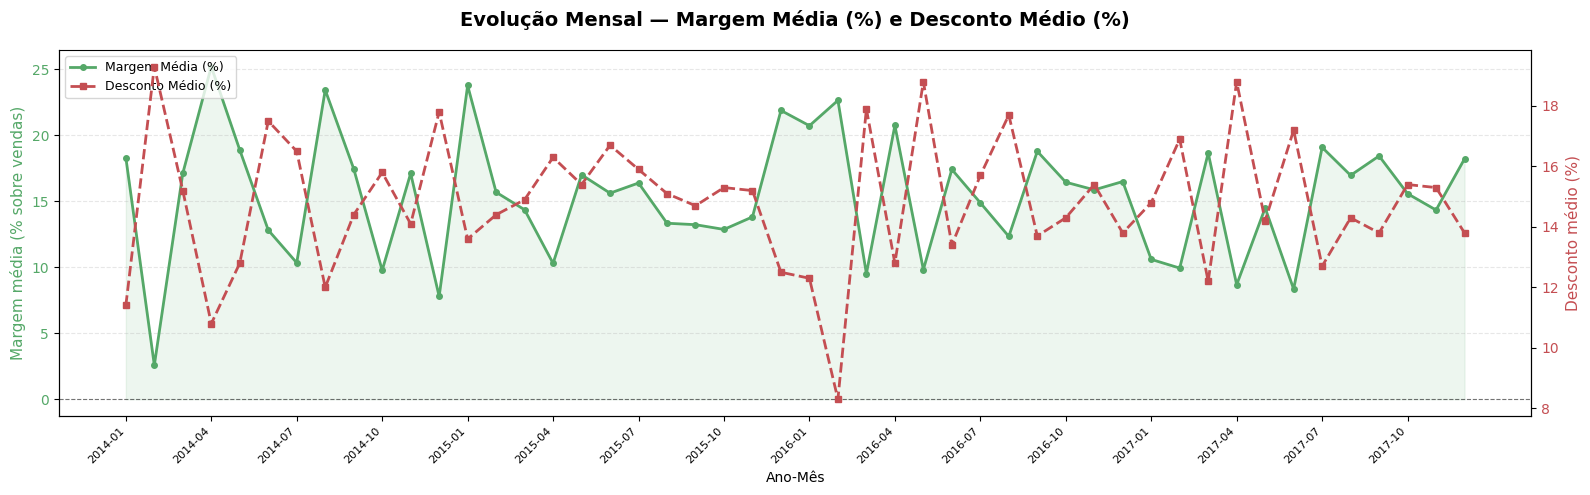


Gráfico salvo: /content/mensal_margem_desconto.png


In [49]:
# ─── 3.5a Desconto × Lucro — Tabela Mês a Mês ──────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Garantir que order_date está em datetime
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])

# Criar coluna de Ano-Mês
df_clean['ano_mes'] = df_clean['order_date'].dt.to_period('M')

# Agrupar por mês: margem média e desconto médio
mensal = (df_clean.groupby('ano_mes')
          .agg(
              margem_media=('pct_lucro', 'mean'),
              desconto_medio=('discount', 'mean'),
              vendas_total=('sales', 'sum'),
              n_pedidos=('order_id', 'nunique')
          )
          .reset_index()
         )

mensal['ano_mes_str'] = mensal['ano_mes'].astype(str)
mensal['desconto_pct'] = (mensal['desconto_medio'] * 100).round(1)
mensal['margem_pct']   = (mensal['margem_media']   * 100).round(2)

print('=== Margem Média (%) e Desconto Médio — Mês a Mês ===')
print(mensal[['ano_mes_str', 'margem_pct', 'desconto_pct', 'n_pedidos']].to_string(index=False))

# Correlação mensal desconto x margem
from scipy import stats
r_men, p_men = stats.pearsonr(mensal['desconto_medio'], mensal['margem_media'])
print(f'\nCorrelação mensal (Desconto x Margem): r = {r_men:.4f}  (p-value = {p_men:.2e})')

# ─── Gráfico de linhas: Ano-Mês × Margem Média (%) e Desconto Médio (%) ────
fig, ax1 = plt.subplots(figsize=(16, 5))
fig.suptitle('Evolução Mensal — Margem Média (%) e Desconto Médio (%)', fontsize=14, fontweight='bold')

x = range(len(mensal))
labels = mensal['ano_mes_str'].tolist()

# Linha 1 — Margem média (%)
cor_margem = '#55A868'
ax1.plot(x, mensal['margem_pct'], color=cor_margem, linewidth=2, marker='o', markersize=4, label='Margem Média (%)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.fill_between(x, 0, mensal['margem_pct'],
                 where=(mensal['margem_pct'] >= 0), alpha=0.1, color=cor_margem)
ax1.fill_between(x, 0, mensal['margem_pct'],
                 where=(mensal['margem_pct'] < 0),  alpha=0.15, color='#C44E52')
ax1.set_ylabel('Margem média (% sobre vendas)', color=cor_margem, fontsize=11)
ax1.tick_params(axis='y', labelcolor=cor_margem)
ax1.set_xlabel('Ano-Mês')

# Linha 2 — Desconto médio (%) no eixo secundário
cor_desc = '#C44E52'
ax2 = ax1.twinx()
ax2.plot(x, mensal['desconto_pct'], color=cor_desc, linewidth=2, marker='s',
         markersize=4, linestyle='--', label='Desconto Médio (%)')
ax2.set_ylabel('Desconto médio (%)', color=cor_desc, fontsize=11)
ax2.tick_params(axis='y', labelcolor=cor_desc)

# Eixo X — rótulos a cada 3 meses para não poluir
step = 3
ax1.set_xticks([i for i in x if i % step == 0])
ax1.set_xticklabels([labels[i] for i in x if i % step == 0], rotation=45, ha='right', fontsize=8)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/mensal_margem_desconto.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGráfico salvo: /content/mensal_margem_desconto.png')

=== Desconto Médio e Margem Média por Categoria ===
       category  desconto_medio  lucro_medio  margem_media
      Furniture        0.148428     9.742129      0.113728
Office Supplies        0.152509    10.093083      0.167270
     Technology        0.128195    17.483409      0.149804


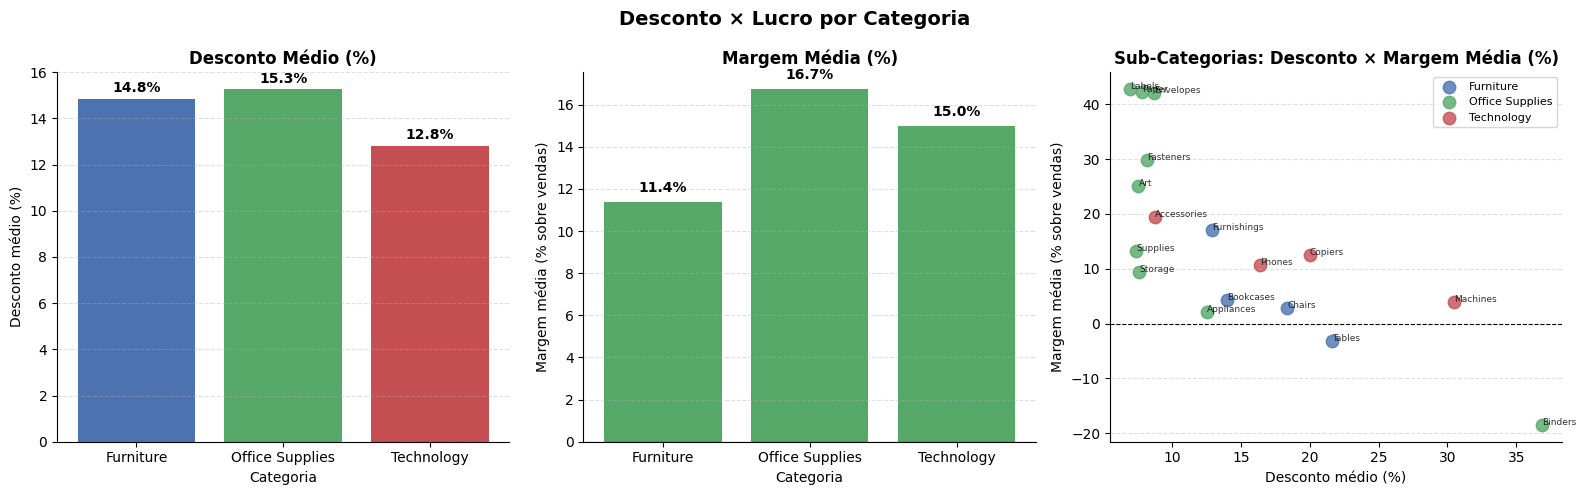


Gráfico salvo: /content/desconto_lucro_categoria.png


In [47]:
# ─── 3.5b Desconto × Lucro por Categoria ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Agrupamento por categoria
cat_grp = (df_clean.groupby('category')
           .agg(
               desconto_medio=('discount', 'mean'),
               lucro_medio=('profit', 'mean'),
               margem_media=('pct_lucro', 'mean'),
               vendas_total=('sales', 'sum')
           )
           .reset_index()
          )

print('=== Desconto Médio e Margem Média por Categoria ===')
print(cat_grp[['category','desconto_medio','lucro_medio','margem_media']].to_string(index=False))

# Gráfico duplo: barras de desconto médio + margem média por categoria
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Desconto × Lucro por Categoria', fontsize=14, fontweight='bold')

cores_cat = ['#4C72B0', '#55A868', '#C44E52']

# Gráfico 1 — Desconto médio
axes[0].bar(cat_grp['category'], cat_grp['desconto_medio']*100, color=cores_cat)
axes[0].set_title('Desconto Médio (%)', fontweight='bold')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Desconto médio (%)')
for ax_i, v in enumerate(cat_grp['desconto_medio']*100):
    axes[0].text(ax_i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Gráfico 2 — Margem média (%)
margem_pct = cat_grp['margem_media'] * 100
cores2 = ['#55A868' if v >= 0 else '#C44E52' for v in margem_pct]
axes[1].bar(cat_grp['category'], margem_pct, color=cores2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Margem Média (%)', fontweight='bold')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Margem média (% sobre vendas)')
for ax_i, v in enumerate(margem_pct):
    axes[1].text(ax_i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Gráfico 3 — Scatter desconto x margem (por sub-categoria)
cat_sub = (df_clean.groupby(['category','sub_category'])
           .agg(desconto=('discount','mean'), margem=('pct_lucro','mean'))
           .reset_index())

color_map = {'Furniture': '#4C72B0', 'Office Supplies': '#55A868', 'Technology': '#C44E52'}
for cat, grp in cat_sub.groupby('category'):
    axes[2].scatter(grp['desconto']*100, grp['margem']*100, label=cat,
                   color=color_map.get(cat,'gray'), s=80, alpha=0.8)
    for _, row in grp.iterrows():
        axes[2].annotate(row['sub_category'], (row['desconto']*100, row['margem']*100),
                         fontsize=6.5, alpha=0.8)

axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Sub-Categorias: Desconto × Margem Média (%)', fontweight='bold')
axes[2].set_xlabel('Desconto médio (%)')
axes[2].set_ylabel('Margem média (% sobre vendas)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/desconto_lucro_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGráfico salvo: /content/desconto_lucro_categoria.png')

=== Desconto Médio e Margem Média por Segmento ===
    segment  desconto_pct  margem_pct  n_pedidos
   Consumer     14.913856   14.808750       2298
  Corporate     15.032176   15.766407       1337
Home Office     14.095615   17.206446        804


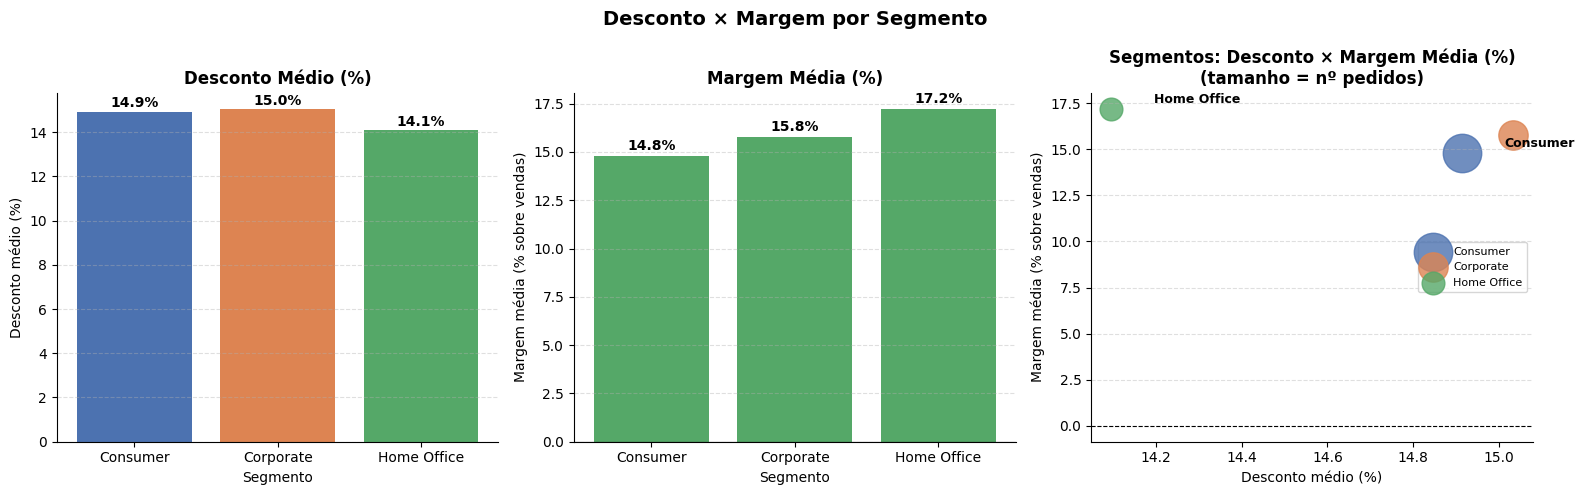


Gráfico salvo: /content/desconto_margem_segmento.png


In [50]:
# ─── 3.5c Desconto × Margem por Segmento ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Agrupamento por segmento
seg_grp = (df_clean.groupby('segment')
           .agg(
               desconto_medio=('discount', 'mean'),
               margem_media=('pct_lucro', 'mean'),
               vendas_total=('sales', 'sum'),
               n_pedidos=('order_id', 'nunique')
           )
           .reset_index()
          )

seg_grp['margem_pct'] = seg_grp['margem_media'] * 100
seg_grp['desconto_pct'] = seg_grp['desconto_medio'] * 100

print('=== Desconto Médio e Margem Média por Segmento ===')
print(seg_grp[['segment','desconto_pct','margem_pct','n_pedidos']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Desconto × Margem por Segmento', fontsize=14, fontweight='bold')

cores_seg = ['#4C72B0', '#DD8452', '#55A868']

# Gráfico 1 — Desconto médio por segmento
axes[0].bar(seg_grp['segment'], seg_grp['desconto_pct'], color=cores_seg)
axes[0].set_title('Desconto Médio (%)', fontweight='bold')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Desconto médio (%)')
for i, v in enumerate(seg_grp['desconto_pct']):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Gráfico 2 — Margem média (%) por segmento
cores2 = ['#55A868' if v >= 0 else '#C44E52' for v in seg_grp['margem_pct']]
axes[1].bar(seg_grp['segment'], seg_grp['margem_pct'], color=cores2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Margem Média (%)', fontweight='bold')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Margem média (% sobre vendas)')
for i, v in enumerate(seg_grp['margem_pct']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Gráfico 3 — Scatter: segmento x desconto x margem (tamanho = nº pedidos)
for i, row in seg_grp.reset_index(drop=True).iterrows():
    axes[2].scatter(row['desconto_pct'], row['margem_pct'],
                   s=row['n_pedidos']/3, color=cores_seg[i], alpha=0.8,
                   label=row['segment'])
    axes[2].annotate(row['segment'],
                     (row['desconto_pct'] + 0.1, row['margem_pct'] + 0.3),
                     fontsize=9, fontweight='bold')

axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Segmentos: Desconto × Margem Média (%)\n(tamanho = nº pedidos)', fontweight='bold')
axes[2].set_xlabel('Desconto médio (%)')
axes[2].set_ylabel('Margem média (% sobre vendas)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/desconto_margem_segmento.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGráfico salvo: /content/desconto_margem_segmento.png')

=== Desconto Médio e Lucro Médio por Região ===
 region  desconto_medio  lucro_medio  margem_media  n_pedidos
   West        0.100173    13.459479      0.247574       1450
  South        0.150895    11.525770      0.173227        740
   East        0.136063    10.922665      0.197506       1231
Central        0.230409     7.893274     -0.044413       1018


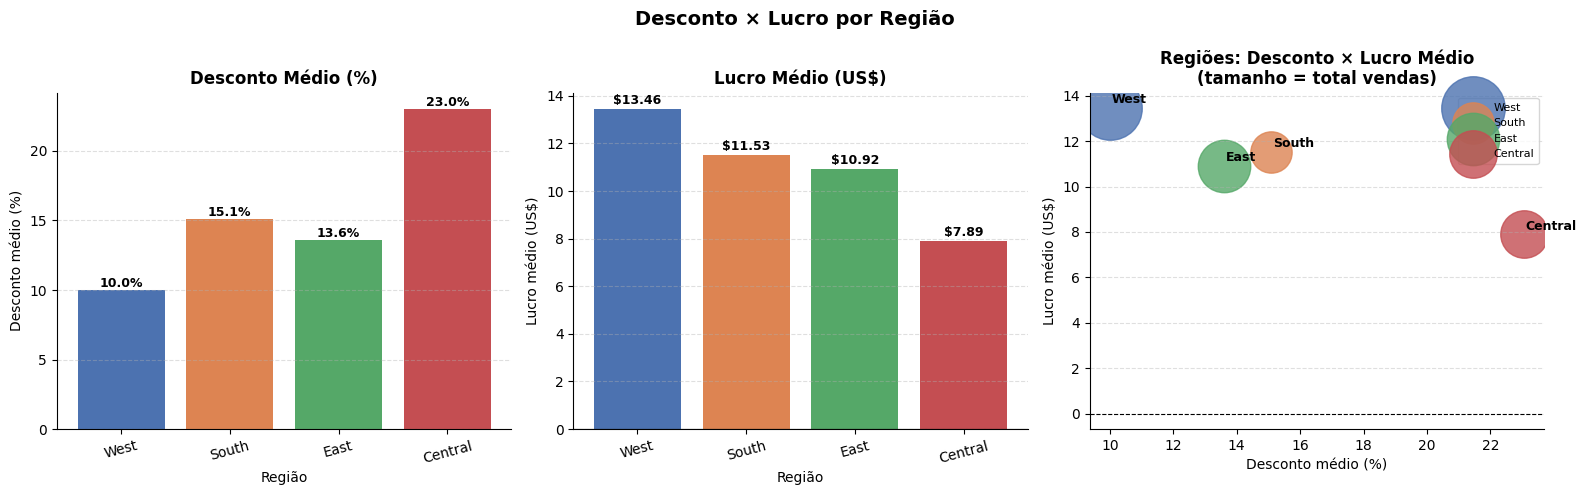


Gráfico salvo: /content/desconto_lucro_regiao.png


In [44]:
# ─── 3.5d Desconto × Lucro por Região ───────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Agrupamento por região
reg_grp = (df_clean.groupby('region')
           .agg(
               desconto_medio=('discount', 'mean'),
               lucro_medio=('profit', 'mean'),
               margem_media=('pct_lucro', 'mean'),
               vendas_total=('sales', 'sum'),
               n_pedidos=('order_id', 'nunique')
           )
           .reset_index()
           .sort_values('lucro_medio', ascending=False)
          )

print('=== Desconto Médio e Lucro Médio por Região ===')
print(reg_grp[['region','desconto_medio','lucro_medio','margem_media','n_pedidos']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Desconto × Lucro por Região', fontsize=14, fontweight='bold')

cores_reg = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Gráfico 1 — Desconto médio por região
bars = axes[0].bar(reg_grp['region'], reg_grp['desconto_medio']*100, color=cores_reg)
axes[0].set_title('Desconto Médio (%)', fontweight='bold')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Desconto médio (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(reg_grp['desconto_medio']*100):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Gráfico 2 — Lucro médio por região
axes[1].bar(reg_grp['region'], reg_grp['lucro_medio'], color=cores_reg)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Lucro Médio (US$)', fontweight='bold')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Lucro médio (US$)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(reg_grp['lucro_medio']):
    axes[1].text(i, v + 0.2, f'${v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Gráfico 3 — Scatter: região x desconto x lucro (tamanho = volume de vendas)
for i, row in reg_grp.reset_index(drop=True).iterrows():
    axes[2].scatter(row['desconto_medio']*100, row['lucro_medio'],
                   s=row['vendas_total']/100, color=cores_reg[i], alpha=0.8,
                   label=row['region'])
    axes[2].annotate(row['region'],
                     (row['desconto_medio']*100 + 0.05, row['lucro_medio'] + 0.2),
                     fontsize=9, fontweight='bold')

axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Regiões: Desconto × Lucro Médio\n(tamanho = total vendas)', fontweight='bold')
axes[2].set_xlabel('Desconto médio (%)')
axes[2].set_ylabel('Lucro médio (US$)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/desconto_lucro_regiao.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGráfico salvo: /content/desconto_lucro_regiao.png')

=== Top 20 Clientes por Total de Vendas ===
  customer_name  vendas_total  desconto_medio  lucro_total  n_pedidos
     Paul Prost     2783.0400        0.111111     407.6147         10
  Arthur Gainer     2698.4510        0.150000      93.3810          9
  William Brown     2511.5830        0.170000     330.3055         11
     Joel Eaton     2460.7610        0.113889     330.7467         12
  Adrian Barton     2164.7960        0.207143     128.1500          8
  Sally Hughsby     2164.4895        0.151923     372.8932         13
    Fred McMath     2158.7780        0.108333     344.1289          9
    Chuck Clark     2134.7220        0.041176     443.1515          9
   Steve Nguyen     2083.7200        0.111765     288.1615          7
   Kunst Miller     2056.3260        0.087500     376.8464          8
   Sanjit Chand     2038.7240        0.066667     269.8636          8
       John Lee     1927.2980        0.056000     412.8366         10
Laura Armstrong     1886.5600        0.152941 

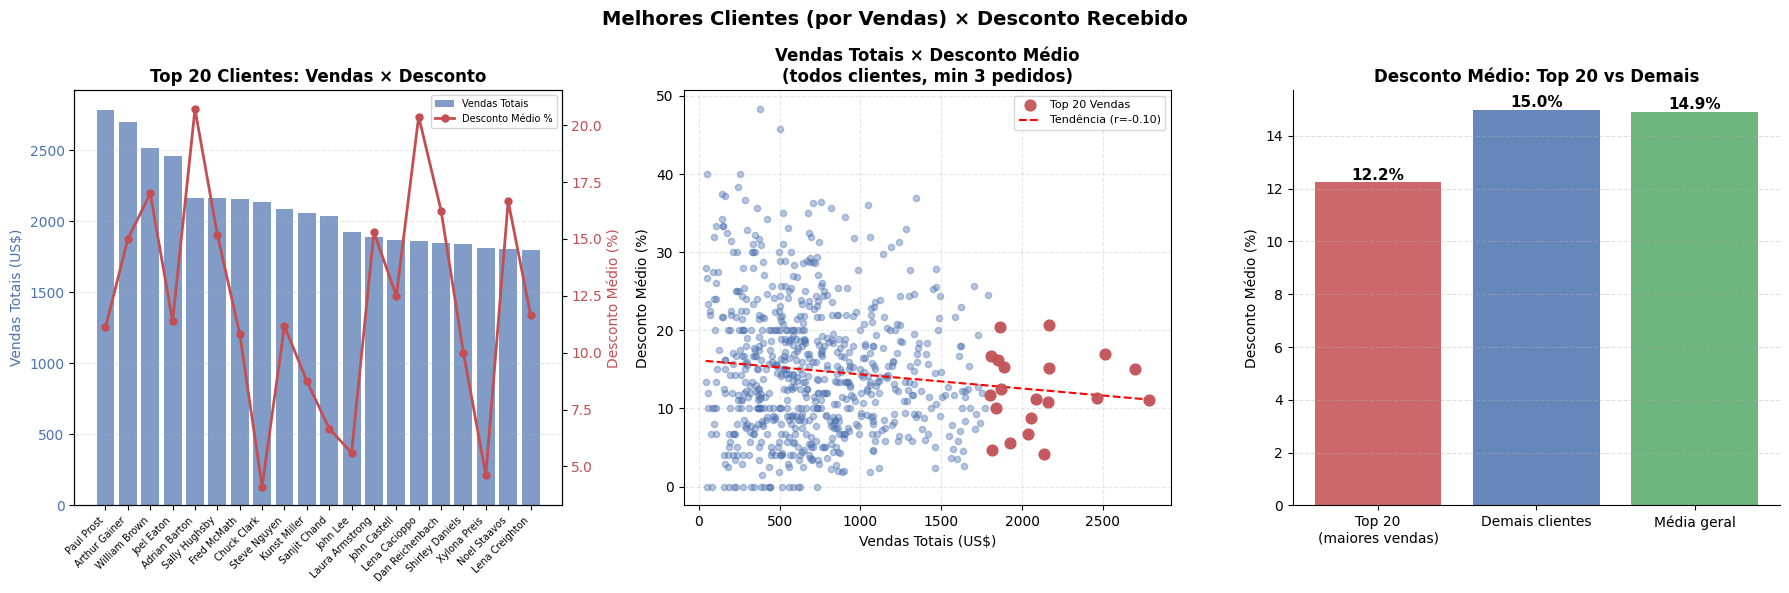


=== Conclusão ===
Desconto médio dos Top 20 clientes (vendas): 12.2%
Desconto médio dos demais clientes:          15.0%
Diferença: -2.7 p.p.
Correlação muito fraca (r=-0.098): NÃO há evidência de que maiores compradores recebam mais desconto.


In [45]:
# ─── 3.5e Os Melhores Clientes (total sales) recebem mais descontos? ─────────
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Agrupamento por cliente
cli_grp = (df_clean.groupby('customer_name')
           .agg(
               vendas_total=('sales', 'sum'),
               lucro_total=('profit', 'sum'),
               desconto_medio=('discount', 'mean'),
               n_pedidos=('order_id', 'nunique'),
               margem_media=('pct_lucro', 'mean')
           )
           .reset_index()
          )

# Top 20 por total de vendas
top20_sales = cli_grp.nlargest(20, 'vendas_total').reset_index(drop=True)
# Top 20 por desconto médio (mínimo 3 pedidos para evitar outliers)
top20_desc = cli_grp[cli_grp['n_pedidos'] >= 3].nlargest(20, 'desconto_medio').reset_index(drop=True)

# Verificar sobreposição
clientes_top_vendas = set(top20_sales['customer_name'])
clientes_top_desc = set(top20_desc['customer_name'])
sobreposicao = clientes_top_vendas & clientes_top_desc

print('=== Top 20 Clientes por Total de Vendas ===')
print(top20_sales[['customer_name','vendas_total','desconto_medio','lucro_total','n_pedidos']].to_string(index=False))
print(f'\nDesconto médio dos top 20 clientes (vendas): {top20_sales["desconto_medio"].mean()*100:.1f}%')
print(f'Desconto médio geral: {cli_grp["desconto_medio"].mean()*100:.1f}%')
print(f'\nClientes que aparecem TANTO no top20 vendas quanto no top20 desconto: {len(sobreposicao)}')
if sobreposicao:
    print('  Nomes:', ', '.join(sorted(sobreposicao)))
else:
    print('  => Nenhuma sobreposição significativa!')

# Correlação entre vendas totais e desconto médio (todos os clientes com >= 3 pedidos)
cli_filtrado = cli_grp[cli_grp['n_pedidos'] >= 3]
r_cli, p_cli = stats.pearsonr(cli_filtrado['vendas_total'], cli_filtrado['desconto_medio'])
print(f'\nCorrelação (vendas totais x desconto médio): r = {r_cli:.4f}  (p-value = {p_cli:.2e})')

# ─── Gráficos ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Melhores Clientes (por Vendas) × Desconto Recebido', fontsize=14, fontweight='bold')

# Gráfico 1 — Top 20 clientes: vendas e desconto médio (barras duplas)
x = np.arange(len(top20_sales))
nomes_curtos = [n.split()[0] + ' ' + n.split()[-1] if len(n.split()) > 1 else n for n in top20_sales['customer_name']]

ax1a = axes[0]
bars1 = ax1a.bar(x, top20_sales['vendas_total'], color='#4C72B0', alpha=0.7, label='Vendas Totais')
ax1a.set_ylabel('Vendas Totais (US$)', color='#4C72B0')
ax1a.tick_params(axis='y', labelcolor='#4C72B0')
ax1b = ax1a.twinx()
ax1b.plot(x, top20_sales['desconto_medio']*100, 'o-', color='#C44E52', linewidth=2, markersize=5, label='Desconto Médio %')
ax1b.set_ylabel('Desconto Médio (%)', color='#C44E52')
ax1b.tick_params(axis='y', labelcolor='#C44E52')
ax1a.set_xticks(x)
ax1a.set_xticklabels(nomes_curtos, rotation=45, ha='right', fontsize=7)
ax1a.set_title('Top 20 Clientes: Vendas × Desconto', fontweight='bold')
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1a.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper right')
ax1a.grid(axis='y', linestyle='--', alpha=0.3)

# Gráfico 2 — Scatter: vendas totais x desconto médio (todos clientes, >= 3 pedidos)
axes[1].scatter(cli_filtrado['vendas_total'], cli_filtrado['desconto_medio']*100,
               alpha=0.4, s=20, color='#4C72B0')
# Destacar top 20
axes[1].scatter(top20_sales['vendas_total'], top20_sales['desconto_medio']*100,
               alpha=0.9, s=60, color='#C44E52', label='Top 20 Vendas', zorder=5)
# Linha de tendência
m, b, r, p, _ = stats.linregress(cli_filtrado['vendas_total'], cli_filtrado['desconto_medio']*100)
x_line = np.linspace(cli_filtrado['vendas_total'].min(), cli_filtrado['vendas_total'].max(), 100)
axes[1].plot(x_line, m*x_line + b, 'r--', linewidth=1.5, label=f'Tendência (r={r:.2f})')
axes[1].set_title('Vendas Totais × Desconto Médio\n(todos clientes, min 3 pedidos)', fontweight='bold')
axes[1].set_xlabel('Vendas Totais (US$)')
axes[1].set_ylabel('Desconto Médio (%)')
axes[1].legend(fontsize=8)
axes[1].grid(linestyle='--', alpha=0.3)

# Gráfico 3 — Comparação: desconto médio dos top20 vs demais
desc_top20 = top20_sales['desconto_medio'].mean() * 100
desc_outros = cli_grp[~cli_grp['customer_name'].isin(clientes_top_vendas)]['desconto_medio'].mean() * 100
desc_geral = cli_grp['desconto_medio'].mean() * 100

grupos = ['Top 20\n(maiores vendas)', 'Demais clientes', 'Média geral']
valores = [desc_top20, desc_outros, desc_geral]
cores3 = ['#C44E52', '#4C72B0', '#55A868']
bars3 = axes[2].bar(grupos, valores, color=cores3, alpha=0.85)
for i, v in enumerate(valores):
    axes[2].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Desconto Médio: Top 20 vs Demais', fontweight='bold')
axes[2].set_ylabel('Desconto Médio (%)')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/melhores_clientes_desconto.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== Conclusão ===')
print(f'Desconto médio dos Top 20 clientes (vendas): {desc_top20:.1f}%')
print(f'Desconto médio dos demais clientes:          {desc_outros:.1f}%')
print(f'Diferença: {desc_top20 - desc_outros:+.1f} p.p.')
if abs(r_cli) < 0.2:
    print(f'Correlação muito fraca (r={r_cli:.3f}): NÃO há evidência de que maiores compradores recebam mais desconto.')
elif r_cli > 0:
    print(f'Correlação positiva (r={r_cli:.3f}): clientes com MAIS vendas tendem a receber desconto MAIOR.')
else:
    print(f'Correlação negativa (r={r_cli:.3f}): clientes com mais vendas tendem a receber desconto MENOR.')

4.Construção de dashboard (opcional):
○ Desenvolvimento de um dashboard interativo utilizando o Looker Studio;
○ Apresentação de indicadores-chave (KPIs);
○ Inclusão de visualizações gráfi cas;

In [51]:
# ─── Salvar df_clean com todas as colunas em Local_Superstore_EDA.csv ────────
import pandas as pd

# Remover a coluna auxiliar 'ano_mes' (Period, não serializável diretamente)
# e salvar todas as demais colunas criadas durante a análise
cols_salvar = [c for c in df_clean.columns if c != 'ano_mes']
df_export = df_clean[cols_salvar].copy()

caminho = '/content/Local_Superstore_EDA.csv'
df_export.to_csv(caminho, index=False, encoding='utf-8')

print(f'Arquivo salvo em: {caminho}')
print(f'Linhas: {len(df_export):,}  |  Colunas: {len(df_export.columns)}')
print(f'\nColunas salvas:')
for col in df_export.columns:
    print(f'  - {col}  ({df_export[col].dtype})')

Arquivo salvo em: /content/Local_Superstore_EDA.csv
Linhas: 7,874  |  Colunas: 25

Colunas salvas:
  - row_id  (int64)
  - order_id  (object)
  - order_date  (datetime64[ns])
  - ship_date  (datetime64[ns])
  - ship_mode  (object)
  - customer_id  (object)
  - customer_name  (object)
  - segment  (object)
  - country  (object)
  - city  (object)
  - state  (object)
  - postal_code  (int64)
  - region  (object)
  - product_id  (object)
  - category  (object)
  - sub_category  (object)
  - product_name  (object)
  - sales  (float64)
  - quantity  (int64)
  - discount  (float64)
  - profit  (float64)
  - dias_para_entrega  (int64)
  - pct_lucro  (float64)
  - ano  (int32)
  - mes  (int32)
